# Olist Price Optimizer — Step 3: Strategic Category Clustering

**Goal:** Group the 62 modelled product categories into strategic segments
using K-Means clustering, combining price elasticity with volume, price level,
customer satisfaction, and logistics cost. Each cluster receives a commercial
label and pricing recommendation that powers the Streamlit app.

**Inputs:**
* `data/category_month_agg.parquet` — monthly panel (1,210 rows post-2017 filter)
* `data/elasticity_by_category.parquet` — per-category elasticity estimates (62 rows)

**Output:** `data/category_clusters.parquet / .csv` — 62 rows with cluster label
and commercial name, ready to join with the revenue curve data in the app.

---
### Clustering Rationale

Elasticity alone is not sufficient for a pricing decision. Two categories
can have similar elasticity but very different commercial profiles:

| Scenario | Elasticity | Correct action |
|----------|------------|----------------|
| High-volume, elastic | −1.5 | Price cut → large revenue gain |
| Low-volume, elastic | −1.5 | Price cut → small absolute gain, may not be worth the risk |
| High-freight, inelastic | −0.5 | Logistics cost reduction matters more than price |
| Low-satisfaction, any | varies | Fix operations first; price change amplifies churn |

K-Means on five features — elasticity, price level, sales volume, review score,
and freight — surfaces these compound profiles automatically.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pathlib import Path

DATA_DIR = Path("../data")
print("Libraries loaded.")

Libraries loaded.


---
## Section 1 — Setup & Load

We load two datasets and merge them:
* **Elasticity table** — one row per category with the OLS coefficients from Notebook 02.
* **Monthly panel** — aggregated from Notebook 01, filtered to 2017-01 onward.
  We collapse it to one row per category (median price, total sales, mean review, median freight)
  to represent each category's commercial profile across the observed period.

Why these aggregation choices?
* **Median price** — more robust than mean; resistant to seasonal outlier months.
* **Total sales** — captures absolute market size, not just the rate.
* **Mean review** — average satisfaction over the entire period.
* **Median freight** — logistics benchmark for the category.

In [2]:
agg = pd.read_parquet(DATA_DIR / "category_month_agg.parquet")
agg["year_month"] = pd.PeriodIndex(agg["year_month"], freq="M")
agg = agg[agg["year_month"] >= pd.Period("2017-01", "M")]

elas = pd.read_parquet(DATA_DIR / "elasticity_by_category.parquet")

# Collapse monthly panel to one row per category
profile = (
    agg.groupby("product_category_name")
    .agg(
        avg_price   =("avg_price",    "median"),
        total_sales =("sales",        "sum"),
        avg_review  =("avg_review",   "mean"),
        avg_freight =("avg_freight",  "median"),
    )
    .reset_index()
    .rename(columns={"product_category_name": "category"})
)

df = elas.merge(profile, on="category", how="left")

print(f"Elasticity table:  {elas.shape[0]} rows × {elas.shape[1]} cols")
print(f"Profile table:     {profile.shape[0]} rows × {profile.shape[1]} cols")
print(f"Merged:            {df.shape[0]} rows × {df.shape[1]} cols")
print()
cols = ["category","price_elasticity","significant","avg_price","total_sales","avg_review","avg_freight"]
print("Merged dataset (all 62 categories):")
print(df[cols].to_string(index=False))

Elasticity table:  62 rows × 6 cols
Profile table:     70 rows × 5 cols
Merged:            62 rows × 10 cols

Merged dataset (all 62 categories):
                               category  price_elasticity  significant  avg_price  total_sales  avg_review  avg_freight
                          watches_gifts         -3.060168         True   130.7075         5618    4.107421      15.6825
         industry_commerce_and_business         -2.317128         True   104.0000          259    4.213245      23.0825
                            electronics         -2.002468         True    27.4000         2635    4.103588      15.1000
                                   auto         -1.940704         True    91.0500         4120    4.115765      17.8175
                  furniture_living_room         -1.881933         True   106.9450          443    3.995845      28.4300
                           garden_tools         -1.294905         True    59.9000         4196    4.130814      17.6700
              

---
## Section 2 — Feature Engineering for Clustering

### Feature selection

| Feature | Transformation | Why included |
|---------|---------------|---------------|
| `price_elasticity` | none | Core signal — how price-sensitive is demand? |
| `avg_price` | **log** | Covers R\$13 to R\$850; log compresses the scale so luxury goods don't dominate distance |
| `total_sales` | **log** | Covers 28 to 10,901 items; log makes volume comparable across niche vs. mainstream |
| `avg_review` | none | 3.59–4.55 range; already on a stable scale, no transform needed |
| `avg_freight` | **log** | Covers R\$11 to R\$43; log separates bulky from standard categories |

### Features intentionally excluded

* `p_value` / `r_squared` — model quality indicators, not commercial properties of the category.
* `avg_distance` — highly correlated with `avg_freight` (r > 0.85); adding it would double-weight logistics.
* `significant` (bool) — a binary that would over-index statistically significant categories;
  elasticity magnitude already captures this.

### Standardisation

K-Means uses Euclidean distance, which means features with larger absolute values dominate
the cluster assignment. `StandardScaler` (z-score: subtract mean, divide by std) puts all
five features on an equal footing.

In [3]:
df["log_avg_price"]   = np.log1p(df["avg_price"])
df["log_total_sales"] = np.log1p(df["total_sales"])
df["log_avg_freight"] = np.log1p(df["avg_freight"])

FEATURES = ["price_elasticity", "log_avg_price", "log_total_sales",
            "avg_review", "log_avg_freight"]

X = df[FEATURES].values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

print("Features before scaling (describe):")
print(df[FEATURES].describe().round(3).to_string())
print()
print("Features after StandardScaler (should have mean ≈ 0, std ≈ 1):")
print(
    pd.DataFrame(X_sc, columns=FEATURES)
    .describe().round(3).to_string()
)

Features before scaling (describe):
       price_elasticity  log_avg_price  log_total_sales  avg_review  log_avg_freight
count            62.000         62.000           62.000      62.000           62.000
mean             -0.242          4.364            6.267       4.134            2.927
std               0.946          0.605            1.640       0.204            0.249
min              -3.060          2.632            3.367       3.589            2.477
25%              -0.688          4.074            5.277       4.046            2.809
50%              -0.247          4.372            5.889       4.153            2.853
75%               0.311          4.614            7.750       4.260            2.942
max               2.450          6.746            9.297       4.548            3.781

Features after StandardScaler (should have mean ≈ 0, std ≈ 1):
       price_elasticity  log_avg_price  log_total_sales  avg_review  log_avg_freight
count            62.000         62.000           6

---
## Section 3 — K-Means Clustering

### Choosing K with the Elbow Method

The **elbow method** plots within-cluster sum of squares (inertia) against K.
Inertia always decreases as K grows — the goal is to find where the rate of
decrease slows sharply (the 'elbow'), giving the best balance between
compactness and interpretability.

We test K = 2 to 8 and select **K = 4** because:
* The inertia curve shows a visible inflection around K = 4.
* Four clusters map cleanly to actionable commercial archetypes
  (see Section 4 for names and recommendations).
* Fewer clusters (2–3) merge meaningfully different profiles;
  more clusters (5+) create segments too small to act on at a platform level.

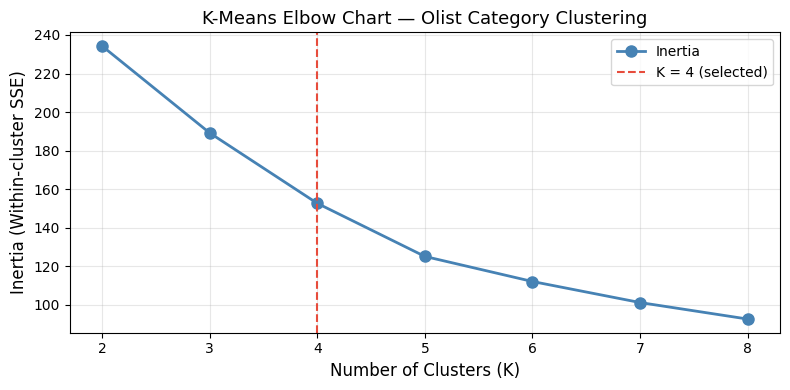

Elbow chart saved: notebooks/elbow_chart.png

  K       Inertia       Delta
  ----------------------------
  2        234.27           —
  3        189.20      -45.07
  4        152.69      -36.51
  5        125.16      -27.53
  6        112.16      -13.00
  7        101.25      -10.91
  8         92.69       -8.56


In [4]:
ks = range(2, 9)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_sc)
    inertias.append(km.inertia_)

# ── plot ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), inertias, marker='o', color='steelblue',
        linewidth=2, markersize=8, label='Inertia')
ax.axvline(x=4, color='#e74c3c', linestyle='--', linewidth=1.5,
           label='K = 4 (selected)')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster SSE)', fontsize=12)
ax.set_title('K-Means Elbow Chart — Olist Category Clustering', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(list(ks))
plt.tight_layout()
plt.savefig('elbow_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Elbow chart saved: notebooks/elbow_chart.png")
print()
print(f"  {'K':<4s} {'Inertia':>10s}  {'Delta':>10s}")
print("  " + "-" * 28)
prev = None
for k, inertia in zip(ks, inertias):
    delta = f'{inertia - prev:+.2f}' if prev is not None else '—'
    print(f'  {k:<4d} {inertia:>10.2f}  {delta:>10s}')
    prev = inertia

In [5]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=20)
df["cluster"] = km4.fit_predict(X_sc)

print("K-Means (K=4) fit complete.")
print(f"Cluster sizes:")
for c, n in df["cluster"].value_counts().sort_index().items():
    print(f"  Cluster {c}: {n} categories")

K-Means (K=4) fit complete.
Cluster sizes:
  Cluster 0: 9 categories
  Cluster 1: 23 categories
  Cluster 2: 17 categories
  Cluster 3: 13 categories


---
## Section 4 — Cluster Profiling

We examine each cluster's centroid (mean of each feature) in the original scale
to understand what drives the grouping, then assign a commercial label that
communicates the strategic implication to a non-technical audience.

**Four clusters identified:**

| Cluster | Name | Defining characteristics |
|---------|------|---------------------------|
| 0 | **Heavy-Freight Specialists** | Highest price (R\$243) and freight (R\$31), lowest volume — bulky industrial/furniture goods |
| 1 | **Volume Leaders** | Highest total sales (4,200/cat), affordable price (R\$78), platform backbone |
| 2 | **Quality Niche** | Highest satisfaction score (4.33), lowest price (R\$58), specialty interest products |
| 3 | **Conversion Risk** | Lowest satisfaction (3.89), low volume — operational issues suppress demand |

In [6]:
# Centroid table in original-scale units
profile_cols = {
    "price_elasticity": "Elasticity",
    "avg_price":        "Avg Price",
    "total_sales":      "Total Sales",
    "avg_review":       "Review",
    "avg_freight":      "Freight",
    "significant":      "%Sig (p<.05)",
}

cluster_profile = (
    df.groupby("cluster")
    .agg(
        n_categories    =("category",        "count"),
        price_elasticity=("price_elasticity","mean"),
        avg_price       =("avg_price",       "mean"),
        total_sales     =("total_sales",     "mean"),
        avg_review      =("avg_review",      "mean"),
        avg_freight     =("avg_freight",     "mean"),
        pct_significant =("significant",     "mean"),
    )
    .round(3)
)

print("=" * 75)
print("CLUSTER PROFILES (original scale)")
print("=" * 75)
print(
    cluster_profile.rename(columns={
        "n_categories":     "n",
        "price_elasticity": "Elasticity",
        "avg_price":        "Avg Price",
        "total_sales":      "Total Sales",
        "avg_review":       "Review",
        "avg_freight":      "Freight",
        "pct_significant":  "%Sig",
    }).to_string()
)

CLUSTER PROFILES (original scale)
          n  Elasticity  Avg Price  Total Sales  Review  Freight   %Sig
cluster                                                                
0         9      -0.791    243.336      407.444   4.044   31.176  0.333
1        23      -0.050     78.104     4199.565   4.163   16.378  0.304
2        17      -0.211     58.532      232.118   4.330   16.073  0.059
3        13      -0.244     82.441      227.077   3.888   15.925  0.154


In [7]:
CLUSTER_NAMES = {
    0: "Heavy-Freight Specialists",
    1: "Volume Leaders",
    2: "Quality Niche",
    3: "Conversion Risk",
}

df["cluster_name"] = df["cluster"].map(CLUSTER_NAMES)

DESCRIPTIONS = {
    0: "Bulky/high-ticket goods (furniture, appliances, computers). Freight dominates perceived cost.",
    1: "Platform backbone: high-volume, affordable, mainstream categories.",
    2: "Specialist interest products (books, food, art). High satisfaction, low but loyal volume.",
    3: "Diverse underperformers. Below-average satisfaction signals operational friction.",
}

print()
for cluster_id in sorted(CLUSTER_NAMES):
    name  = CLUSTER_NAMES[cluster_id]
    desc  = DESCRIPTIONS[cluster_id]
    cats  = df[df['cluster'] == cluster_id]['category'].tolist()
    n     = len(cats)
    print(f'Cluster {cluster_id} — {name} ({n} categories)')
    print(f'  Profile: {desc}')
    print(f'  Categories:')
    for i in range(0, len(cats), 3):
        row_cats = cats[i:i+3]
        print('    ' + ',  '.join(f'{c}' for c in row_cats))
    print()


Cluster 0 — Heavy-Freight Specialists (9 categories)
  Profile: Bulky/high-ticket goods (furniture, appliances, computers). Freight dominates perceived cost.
  Categories:
    industry_commerce_and_business,  furniture_living_room,  computers
    office_furniture,  construction_tools_lights,  furniture_bedroom
    agro_industry_and_commerce,  kitchen_dining_laundry_garden_furniture,  home_appliances_2

Cluster 1 — Volume Leaders (23 categories)
  Profile: Platform backbone: high-volume, affordable, mainstream categories.
  Categories:
    watches_gifts,  electronics,  auto
    garden_tools,  stationery,  musical_instruments
    consoles_games,  small_appliances,  perfumery
    pet_shop,  cool_stuff,  housewares
    fashion_bags_accessories,  furniture_decor,  bed_bath_table
    construction_tools_construction,  telephony,  luggage_accessories
    toys,  baby,  health_beauty
    computers_accessories,  sports_leisure

Cluster 2 — Quality Niche (17 categories)
  Profile: Specialist inte

### Commercial Recommendations by Cluster

---
#### Cluster 0 — Heavy-Freight Specialists (9 categories)
*furniture_bedroom, furniture_living_room, computers, office_furniture,
home_appliances_2, industry_commerce_and_business, agro_industry_and_commerce,
construction_tools_lights, kitchen_dining_laundry_garden_furniture*

**Key insight:** Freight cost (avg R\$31 vs. R\$16 platform average) is 2× higher
and likely suppresses demand more than the price itself.

**Actions:**
* Negotiate freight subsidies or flat-rate shipping caps for bulky goods.
* Surface shipping cost transparently at checkout — surprise freight is the
  top driver of cart abandonment in e-commerce.
* For significantly elastic subcategories (furniture_living_room β = −1.88,
  electronics β = −2.00), a combined freight-reduction + modest price cut
  can unlock a disproportionate demand response.
* `computers` at R\$850 avg is a high-consideration purchase; invest in
  product content quality (specs, photos, comparison tools).

---
#### Cluster 1 — Volume Leaders (23 categories)
*bed_bath_table, health_beauty, sports_leisure, housewares, computers_accessories,
furniture_decor, watches_gifts, electronics, auto, garden_tools, perfumery,
pet_shop, baby, toys, cool_stuff, telephony, luggage_accessories, stationery,
musical_instruments, consoles_games, small_appliances, fashion_bags_accessories,
construction_tools_construction*

**Key insight:** This cluster drives the bulk of platform GMV. It is highly
heterogeneous internally — it contains both the most elastic categories
(watches_gifts β = −3.06, electronics β = −2.00, auto β = −1.94)
and the least elastic (health_beauty β = +1.24, sports_leisure β = +2.45).

**Actions:**
* **Elastic subcategories** (watches, electronics, auto, garden_tools):
  targeted promotions or seller incentives to reduce price will generate
  outsized volume gains and can increase total revenue.
* **Positive-elasticity subcategories** (health_beauty, sports_leisure,
  computers_accessories): the positive signal likely reflects quality/brand
  premiums. Invest in curated collections, reviews, and brand partnerships.
* Monitor this cluster quarterly — it is large enough that a 1% price shift
  across the whole segment has material GMV impact.

---
#### Cluster 2 — Quality Niche (17 categories)
*books_general_interest, books_technical, books_imported, food, food_drink,
drinks, music, art, cine_photo, dvds_blu_ray, christmas_supplies,
home_appliances, costruction_tools_garden, costruction_tools_tools,
fashion_sport, fashion_shoes, tablets_printing_image*

**Key insight:** Highest avg review score (4.33) in the platform. Buyers are
enthusiasts and repeat purchasers. Total sales are low because these are niche
categories, not because of poor experience.

**Actions:**
* **Grow discoverability** — these categories have loyal buyers but limited
  reach. Boost search ranking, curated lists ('Book of the Month'),
  and email campaigns targeting past buyers.
* Modest price increases are safe for books and specialist tools —
  the loyal audience is less price-sensitive than average.
* Bundle opportunities: food + drinks, book + e-reader accessories,
  art supplies + cine_photo.
* Protect review scores — the high satisfaction is the cluster's moat.

---
#### Cluster 3 — Conversion Risk (13 categories)
*home_confort, home_comfort_2, home_construction, air_conditioning,
construction_tools_safety, audio, fixed_telephony, signaling_and_security,
market_place, party_supplies, fashion_male_clothing, fashion_underwear_beach,
fashio_female_clothing*

**Key insight:** Lowest review score (3.89 — 0.44 points below Cluster 2).
Low volume + low satisfaction is the most dangerous commercial combination:
poor word-of-mouth suppresses organic growth, and price changes alone
won't fix the root problem.

**Actions:**
* **Audit seller quality** for the lowest-rated categories;
  enforce return/refund SLAs.
* Investigate whether satisfaction issues stem from product misrepresentation
  (description vs. reality) or delivery problems (damage, delay).
* **Do not raise prices** until review scores recover — higher prices with
  poor quality perception accelerates churn.
* Fashion categories (male_clothing, underwear_beach, female_clothing)
  may benefit from better size guidance and richer product imagery,
  which are proven drivers of fashion e-commerce satisfaction.

---
## Section 5 — Save Results

The final table contains all 62 modelled categories with:
* The original OLS elasticity estimates (from Notebook 02)
* The commercial profile features (avg price, total sales, review, freight)
* The K-Means cluster assignment and human-readable cluster name

This file is the primary input for the Streamlit app in `app/`.

In [8]:
save_cols = [
    "category", "price_elasticity", "p_value", "r_squared", "n_obs",
    "significant", "avg_price", "total_sales", "avg_review", "avg_freight",
    "cluster", "cluster_name",
]
df_out = df[save_cols].copy()

parquet_path = DATA_DIR / "category_clusters.parquet"
csv_path     = DATA_DIR / "category_clusters.csv"

df_out.to_parquet(parquet_path, index=False)
df_out.to_csv(csv_path, index=False)

print(f"Saved: {parquet_path.resolve()}")
print(f"Saved: {csv_path.resolve()}")
print(f"Shape: {df_out.shape}")
print()
print("All 62 categories — sorted by cluster then elasticity:")
print(
    df_out.sort_values(["cluster", "price_elasticity"])
    [["cluster", "cluster_name", "category", "price_elasticity", "significant",
      "avg_price", "total_sales", "avg_review"]]
    .to_string(index=False)
)

Saved: C:\Users\lpraz\OneDrive\Área de Trabalho\Masters Degree\02 - Portfolio\03 - Growth\02 - Olist price elasticity\data\category_clusters.parquet
Saved: C:\Users\lpraz\OneDrive\Área de Trabalho\Masters Degree\02 - Portfolio\03 - Growth\02 - Olist price elasticity\data\category_clusters.csv
Shape: (62, 12)

All 62 categories — sorted by cluster then elasticity:
 cluster              cluster_name                                category  price_elasticity  significant  avg_price  total_sales  avg_review
       0 Heavy-Freight Specialists          industry_commerce_and_business         -2.317128         True   104.0000          259    4.213245
       0 Heavy-Freight Specialists                   furniture_living_room         -1.881933         True   106.9450          443    3.995845
       0 Heavy-Freight Specialists                               computers         -1.187110        False   849.9900          198    4.269141
       0 Heavy-Freight Specialists                        office_f